# Global GDP Exploratory Data Analysis (EDA)

## Objective
The goal of this project is to analyze global GDP data and uncover patterns, trends, and economic insights using Python.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/cleaned_gdp.csv")
df.head()

,Country,GDP(Million USD),GDP(Billion USD)
0,United States,26854599,26854.60
1,China,19373586,19373.59
2,Japan,4409738,4409.74
3,Germany,4308854,4308.85
4,India,3736882,3736.88


In [ ]:
print(df.columns)

Index(['Country', 'GDP(Million USD)', 'GDP(Billion USD)'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           191 non-null    object 
 1   GDP(Million USD)  191 non-null    int64  
 2   GDP(Billion USD)  191 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.6+ KB


In [ ]:
df.describe(include="all")

,Country,GDP(Million USD),GDP(Billion USD)
count,191,1.910000e+02,191.000000
unique,191,NaN,NaN
top,United States,NaN,NaN
freq,1,NaN,NaN
mean,NaN,5.503501e+05,550.350209
std,NaN,2.461686e+06,2461.686402
min,NaN,6.500000e+01,0.060000
25%,NaN,1.213550e+04,12.135000
50%,NaN,4.487000e+04,44.870000
75%,NaN,2.680640e+05,268.065000


In [ ]:
# Clean GDP column
df["GDP(Million USD)"] = df["GDP(Million USD)"].astype(str).str.replace(",", "").str.strip()

# Convert to numeric
df["GDP(Million USD)"] = pd.to_numeric(df["GDP(Million USD)"], errors="coerce")

# Drop rows where GDP is missing
df.dropna(subset=["GDP(Million USD)"], inplace=True);

# Create GDP in Billion USD for easier analysis
df["GDP(Billion USD)"] = df["GDP(Million USD)"] / 1000

# Check cleaned result
df.head()

,Country,GDP(Million USD),GDP(Billion USD)
0,United States,26854599,26854.599
1,China,19373586,19373.586
2,Japan,4409738,4409.738
3,Germany,4308854,4308.854
4,India,3736882,3736.882


In [ ]:
df.isnull().sum()

,0
Country,0
GDP(Million USD),0
GDP(Billion USD),0


## Data Cleaning Summary

- Removed commas and extra spaces from the GDP column
- Converted GDP values into numeric format
- Removed rows with invalid or missing GDP values
- Created a new GDP column in **Billion USD** for easier visualization

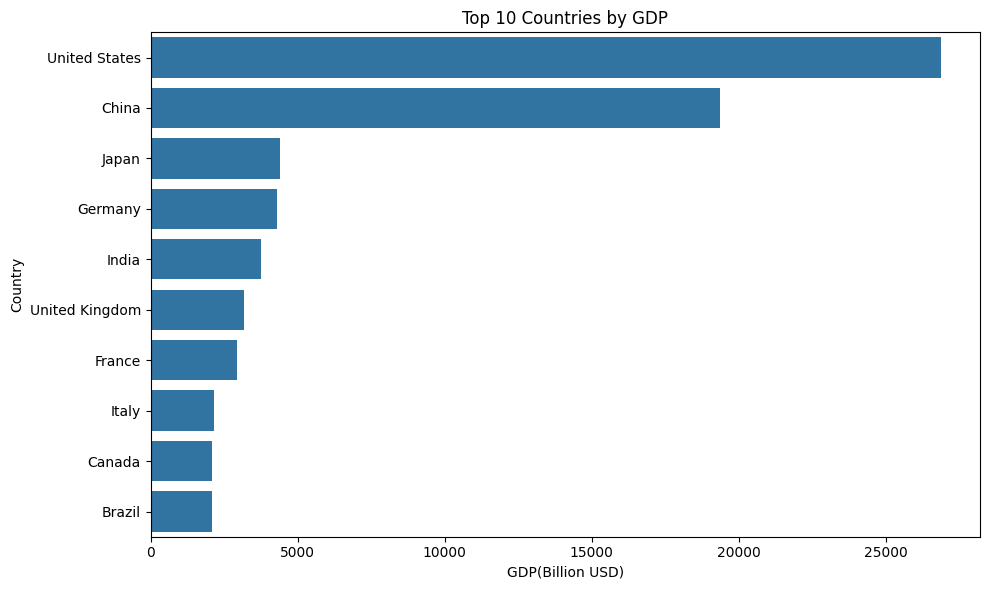

In [ ]:
import os

top10 = df.sort_values("GDP(Billion USD)", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="GDP(Billion USD)", y="Country", data=top10)
plt.title("Top 10 Countries by GDP")
plt.xlabel("GDP(Billion USD)")
plt.ylabel("Country")
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = "/content/outputs/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "top10_gdp.png"))
plt.show()

### Insight
A small number of countries dominate the global economy.  
The top economies contribute a disproportionately large share of total GDP.

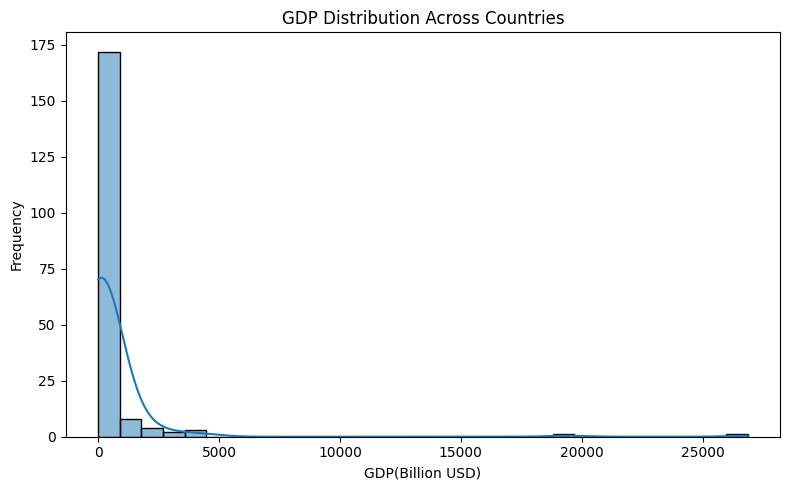

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["GDP(Billion USD)"], bins=30, kde=True)
plt.title("GDP Distribution Across Countries")
plt.xlabel("GDP(Billion USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("/content/outputs/gdp_distribution.png")
plt.show()

### Insight
The GDP distribution is highly right-skewed.  
This means that most countries have relatively low GDP, while a few countries have extremely high GDP.

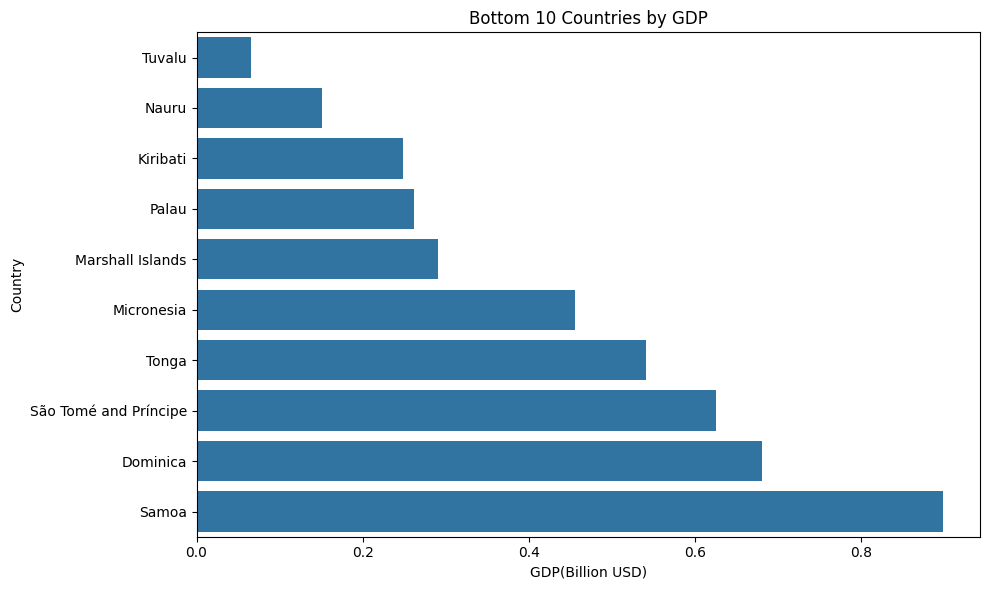

In [ ]:
bottom10 = df.sort_values("GDP(Billion USD)", ascending=True).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="GDP(Billion USD)", y="Country", data=bottom10)
plt.title("Bottom 10 Countries by GDP")
plt.xlabel("GDP(Billion USD)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("/content/outputs/bottom10_gdp.png")
plt.show()

### Insight
Several countries have very low GDP compared to the world's largest economies.  
This highlights the economic imbalance across nations.

## Final Observations

- The global economy is heavily concentrated among a few powerful countries.
- Most countries fall within the lower GDP range.
- GDP distribution is not uniform and shows strong inequality.
- Visual analysis helps reveal economic patterns more clearly than raw tables.